<a href="https://colab.research.google.com/github/Geon0904/Geon0904/blob/main/data-analysis/Salary_of_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salary analysis and prediction for the data science field in the United States in 2023.

## Loading a dataset

In [62]:
# Import necessary libraries for data analysis
import pandas as pd

# Set the file path:
file_path = '/content/drive/MyDrive/데이터분석/ds_salaries.csv'


# Create Data Frames
df = pd.read_csv(file_path)

# Check the results
print(df)


"""
Work Year: The year joined the company
experience level: EN: Entry Level / MI: Mid Level / SE: Senior Level / EX: Executive Level
employment type: FT: Full Time / CT: Contract
job title:
remote_ratio:
company size: The median number of people who have worked for the company in a year, S/ M / L
"""

      work_year experience_level employment_type                 job_title  \
0          2023               SE              FT  Principal Data Scientist   
1          2023               MI              CT               ML Engineer   
2          2023               MI              CT               ML Engineer   
3          2023               SE              FT            Data Scientist   
4          2023               SE              FT            Data Scientist   
...         ...              ...             ...                       ...   
3750       2020               SE              FT            Data Scientist   
3751       2021               MI              FT  Principal Data Scientist   
3752       2020               EN              FT            Data Scientist   
3753       2020               EN              CT     Business Data Analyst   
3754       2021               SE              FT      Data Science Manager   

       salary salary_currency  salary_in_usd employee_residence

'\nWork Year: The year joined the company\nexperience level: EN: Entry Level / MI: Mid Level / SE: Senior Level / EX: Executive Level\nemployment type: FT: Full Time / CT: Contract\njob title:\nremote_ratio:\ncompany size: The median number of people who have worked for the company in a year, S/ M / L\n'

## Data preprocessing:

### Removing unnecessary columns:

In [63]:
import pandas as pd

### Removing unnecessary columns:
df.drop(columns=['salary', 'salary_currency'], inplace=True)

# Extract U.S. data only and remove other countries
df = df[df['employee_residence'] == 'US']

### don't need company_location because only have America left
df.drop(columns=['company_location', 'employee_residence'], inplace=True)

# Verifying and storing extracted data
print(df)

      work_year experience_level employment_type                 job_title  \
1          2023               MI              CT               ML Engineer   
2          2023               MI              CT               ML Engineer   
5          2023               SE              FT         Applied Scientist   
6          2023               SE              FT         Applied Scientist   
9          2023               SE              FT            Data Scientist   
...         ...              ...             ...                       ...   
3749       2021               SE              FT           Data Specialist   
3750       2020               SE              FT            Data Scientist   
3751       2021               MI              FT  Principal Data Scientist   
3752       2020               EN              FT            Data Scientist   
3753       2020               EN              CT     Business Data Analyst   

      salary_in_usd  remote_ratio company_size  
1             

### Missing data treatment

In [64]:
### Check the amount of null data per column
num_nulls = df.isnull().sum()
print(f'Count of Missing Data in Each Column \n{num_nulls}')

Count of Missing Data in Each Column 
work_year           0
experience_level    0
employment_type     0
job_title           0
salary_in_usd       0
remote_ratio        0
company_size        0
dtype: int64


### Outlier identification and mitigation

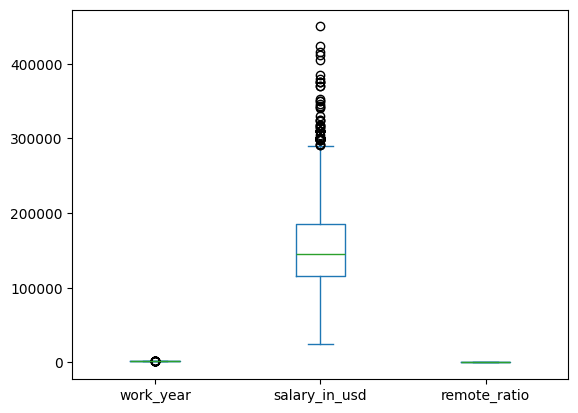

In [65]:
### Visualizing the presence of outliers using box plots in data analysis

# Import necessary library
import matplotlib.pyplot as plt

# Visualize
df.plot(kind='box')
plt.show()

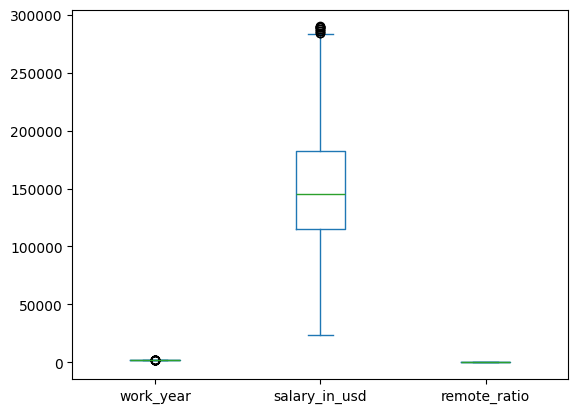

In [66]:
# outlier detection using IQR
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['salary_in_usd'] >= lower_bound) & (df['salary_in_usd'] <= upper_bound)]

# Visualize
df.plot(kind='box')
plt.show()

## EDA(Exploratory Data Analysis)

In [67]:
### Import necessary library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

"""
If there's no correlation, I won't visualize it
"""

"\nIf there's no correlation, I won't visualize it\n"

In [68]:
"""
Correlation Coefficient Analysis Guidelines

over 0.7: a very strong correlation
0.5 ~ 0.7: strong correlation
0.3 ~ 0.5: moderate correlation
0.1 ~ 0.3: weak correlation
under 0.1: little correlation
"""

'\nCorrelation Coefficient Analysis Guidelines\n\nover 0.7: a very strong correlation\n0.5 ~ 0.7: strong correlation\n0.3 ~ 0.5: moderate correlation\n0.1 ~ 0.3: weak correlation\nunder 0.1: little correlation\n'

### Correlation analysis between salary and work year

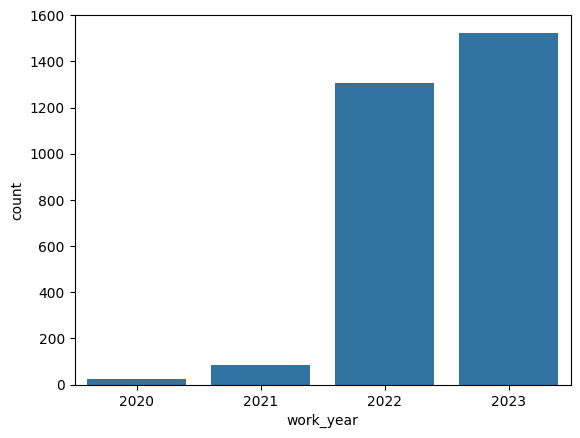

In [69]:
# Visualizing the work_year column
sns.countplot(data=df, x='work_year')
plt.show()

In [70]:
### Correlation analysis
df_corr = df.loc[:,['salary_in_usd', 'work_year']].corr()
print(f'Correlation between salary and work year : \n{df_corr}')

"""
There is almost no correlation. I personally believe this result is due to the possibility of employees gaining experience at other companies before transferring here.
"""

Correlation between salary and work year : 
               salary_in_usd  work_year
salary_in_usd       1.000000   0.087374
work_year           0.087374   1.000000


'\nThere is almost no correlation. I personally believe this result is due to the possibility of employees gaining experience at other companies before transferring here.\n'

### Correlations analysis between salary and experience level

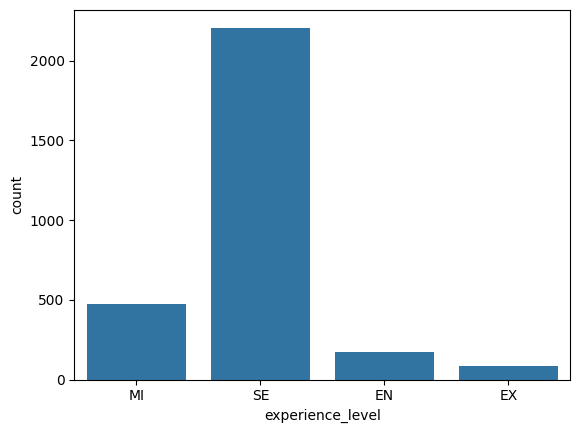

In [71]:
# Visualizing the experience_level column

sns.countplot(data=df, x='experience_level')
plt.show()

Correlation analysis between salary and experience level : 
                          salary_in_usd  experience_level_encoded
salary_in_usd                  1.000000                  0.224279
experience_level_encoded       0.224279                  1.000000
--------------------------------------------------------------------------------


<ipython-input-72-830b40a89ba9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['experience_level_encoded'] = le.fit_transform(df['experience_level'])


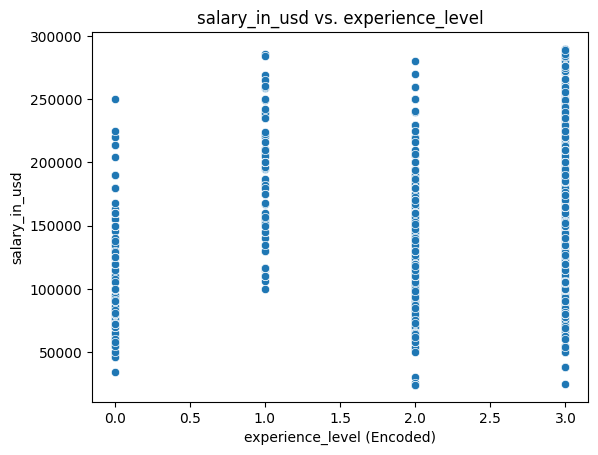

In [72]:
"""
The experience_level column currently consists of object data types, making correlation analysis difficult.
Therefore, we will apply label encoding to convert these categorical values into numerical ones
"""

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])

"""
MI: 0 / SE: 1 / EN: 2 / EX: 3
"""

# Correlation analysis
df_corr = df[['salary_in_usd', 'experience_level_encoded']].corr()
print(f'Correlation analysis between salary and experience level : \n{df_corr}')

print('-'*80)

# Visualize
sns.scatterplot(x='experience_level_encoded', y='salary_in_usd', data=df)
plt.xlabel('experience_level (Encoded)')
plt.ylabel('salary_in_usd')
plt.title('salary_in_usd vs. experience_level')
plt.show()


### Correlations analysis between salary and employment type

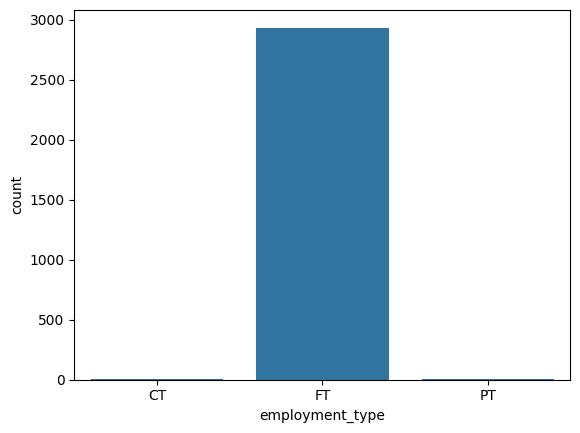

"\nAccording to the graph below, there are few CT and PT, and most of them are FT,\nso I don't think I need to do a relationship analysis.\n"

In [73]:
# Visualizing the employment_type column
sns.countplot(data=df, x='employment_type')
plt.show()

"""
According to the graph below, there are few CT and PT, and most of them are FT,
so I don't think I need to do a relationship analysis.
"""

the correlation coefficient between salary and employment type : 
                         salary_in_usd  employment_type_encoded
salary_in_usd                 1.000000                 0.022509
employment_type_encoded       0.022509                 1.000000
--------------------------------------------------------------------------------


<ipython-input-74-de3204efa374>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['employment_type_encoded'] = le.fit_transform(df['employment_type'])


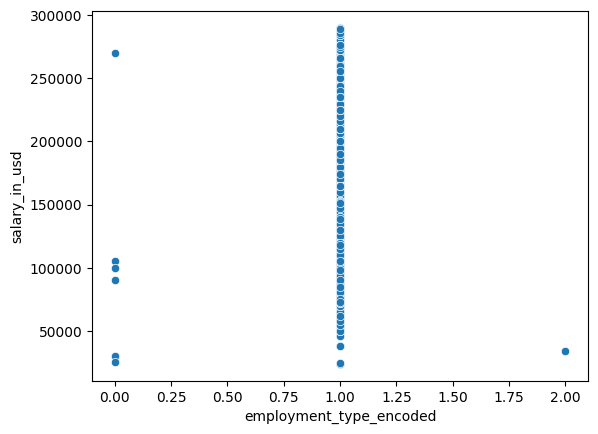

In [74]:
"""
If I had to try
"""

# Label Encoding
le = LabelEncoder()
df['employment_type_encoded'] = le.fit_transform(df['employment_type'])

"""
CT: 0 / FT: 1 / PT: 2
"""

# Correalations analysis
df_corr = df[['salary_in_usd', 'employment_type_encoded']].corr()
print(f'the correlation coefficient between salary and employment type : \n{df_corr}')

print('-'*80)

### Visualize the relationship between salary and employment type
sns.scatterplot(data=df, x='employment_type_encoded', y='salary_in_usd')
plt.show()

### Correlation analysis between salary and job title

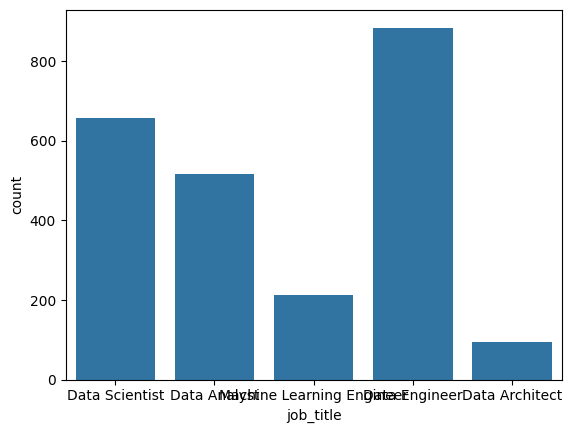

'\nMost Occupational Order:\n0 -> Data Scientists (2nd)\n1 -> Data Analyst (3rd)\n2 -> Machine Learning Engineer (4th)\n3 -> Data Engineer (1st)\n4 -> Data Architect (5th)\n'

In [75]:
# With so many jobs, extracting the top 5 most jobs
top_5_job_titles = df['job_title'].value_counts().nlargest(5).index.tolist()

# Create a new data frame that includes only the top 5 jobs
df1 = df[df['job_title'].isin(top_5_job_titles)]

sns.countplot(data=df1, x='job_title')
plt.show()


"""
Most Occupational Order:
0 -> Data Scientists (2nd)
1 -> Data Analyst (3rd)
2 -> Machine Learning Engineer (4th)
3 -> Data Engineer (1st)
4 -> Data Architect (5th)
"""

the correlation coefficient between salary and job title : 
0.3243486598389422
--------------------------------------------------------------------------------


<ipython-input-76-114b3091161d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['job_title_encoded'] = le.fit_transform(df1['job_title'])


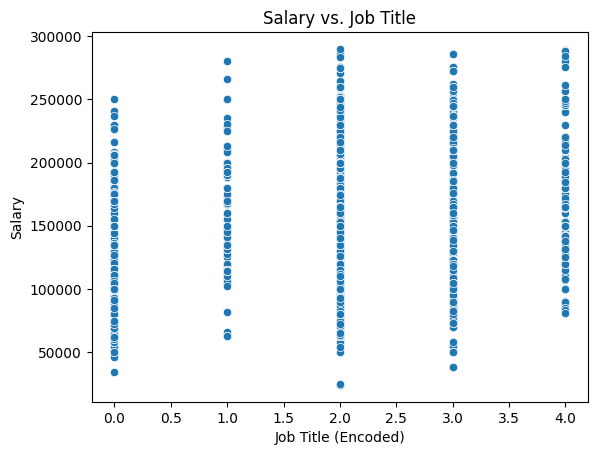

In [76]:
# Label encoding
le = LabelEncoder()
df1['job_title_encoded'] = le.fit_transform(df1['job_title'])

# Correalations analysis
df_corr = df['salary_in_usd'].corr(df1['job_title_encoded'])
print(f'the correlation coefficient between salary and job title : \n{df_corr}')

print('-'*80)

### Visualization of the relationship between salary and job title
merged_df = pd.merge(df, df1)

sns.scatterplot(x='job_title_encoded', y='salary_in_usd', data=merged_df)
plt.xlabel('Job Title (Encoded)')
plt.ylabel('Salary')
plt.title('Salary vs. Job Title')
plt.show()

### Correlation analysis between salary and remote ratio

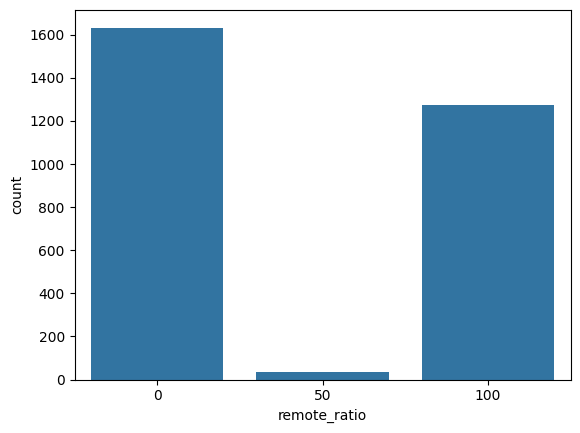

'\nProportion of remote work\n0: If remote_ratio is 0, it means all employees work on-site\n50: A remote_ratio of 50 indicates that 50% of the workforce is remote\n100: A remote_ratio of 100 signifies a fully remote workforce\n'

In [77]:
# Visualization of the remote_ratio column
sns.countplot(data=df, x='remote_ratio')
plt.show()

"""
Proportion of remote work
0: If remote_ratio is 0, it means all employees work on-site
50: A remote_ratio of 50 indicates that 50% of the workforce is remote
100: A remote_ratio of 100 signifies a fully remote workforce
"""

In [78]:
### the correlation coefficient analysis
df_corr = df.loc[:, ['remote_ratio', 'salary_in_usd']].corr()
print(f'the correlation coefficient analysis : \n{df_corr}')

"""
I discovered an unexpected finding that the remote work ratio and salary are largely unrelated.
"""

the correlation coefficient analysis : 
               remote_ratio  salary_in_usd
remote_ratio       1.000000      -0.011523
salary_in_usd     -0.011523       1.000000


'\nI discovered an unexpected finding that the remote work ratio and salary are largely unrelated.\n'

### Correlation analysis between salary and company size

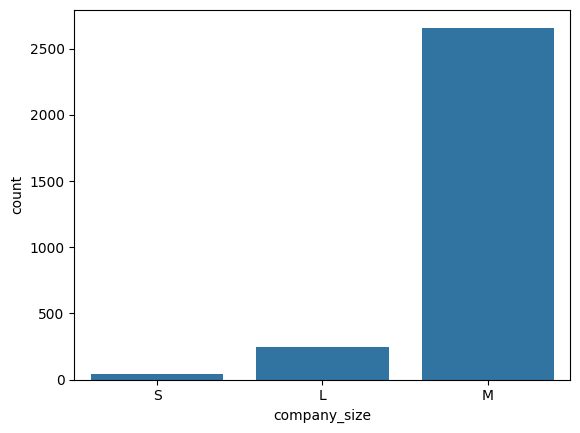

In [79]:
# Visualization of the company_size column
sns.countplot(data=df, x='company_size')
plt.show()

the correlation coefficient analysis between salary and company size : 
               salary_in_usd  company_size
salary_in_usd       1.000000     -0.044197
company_size       -0.044197      1.000000
--------------------------------------------------------------------------------


<ipython-input-80-a6852fa7f1ed>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['company_size'] = le.fit_transform(df['company_size'])


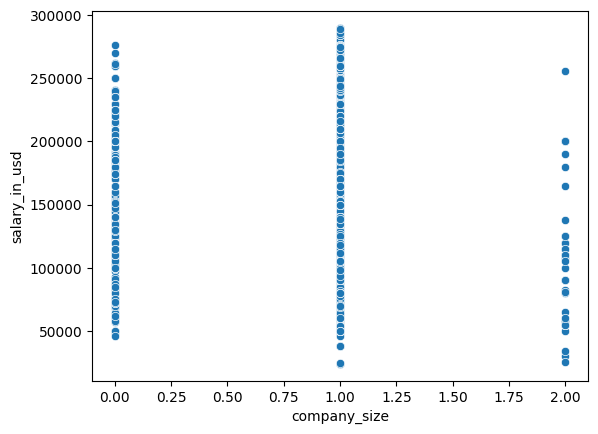

"\nS -> 0 / L -> 1 / M -> 2\n\nSurprisingly, I found that company size (number of employees) didn't have a significant impact on salary.\nHowever, it seems that those with a higher company size (L) tend to earn slightly more.\n"

In [80]:
# Label Encoding
le = LabelEncoder()
df['company_size'] = le.fit_transform(df['company_size'])

# correlation coefficient analysis
df_corr = df[['salary_in_usd', 'company_size']].corr()
print(f'the correlation coefficient analysis between salary and company size : \n{df_corr}')

print('-'*80)

# Visualization
sns.scatterplot(data=df, x='company_size', y='salary_in_usd')
plt.show()

"""
S -> 0 / L -> 1 / M -> 2

Surprisingly, I found that company size (number of employees) didn't have a significant impact on salary.
However, it seems that those with a higher company size (L) tend to earn slightly more.
"""

## The conclusion of the correlations

In [81]:
# Find the top 10 highest salaries
top_10_salaries = df['salary_in_usd'].nlargest(10)

# Filter rows where salary is in the top 5
filtered_df = df[df['salary_in_usd'].isin(top_10_salaries)]

# Print the result
print(filtered_df)

      work_year experience_level employment_type                  job_title  \
117        2023               SE              FT         Analytics Engineer   
123        2023               SE              FT         Analytics Engineer   
377        2023               SE              FT  Machine Learning Engineer   
472        2023               EX              FT              Data Engineer   
1093       2023               SE              FT              Data Engineer   
1185       2023               SE              FT  Machine Learning Engineer   
1187       2023               SE              FT  Machine Learning Engineer   
1271       2023               SE              FT  Machine Learning Engineer   
1460       2023               SE              FT             Data Scientist   
1724       2023               SE              FT                ML Engineer   

      salary_in_usd  remote_ratio  company_size  experience_level_encoded  \
117          289800             0             1      

In [82]:
"""
1. Many of the high-earners joined the company in 2023, suggesting they may have leveraged their experience from previous roles to negotiate higher salaries.
2. To command such high salaries, individuals typically need to attain at least a Senior Engineer level, highlighting the importance of experience and technical skills.
3. All employees in this dataset are full-time, indicating that the high salaries are not due to atypical employment arrangements like internships or contract work.
4. Machine learning engineers constitute a significant portion of the high-earners.
5. All companies in the dataset are large (categorized as L), with roughly 50% of employees working remotely.
6. The average salary for this group is a substantial $259,186.
"""

'\n1. Many of the high-earners joined the company in 2023, suggesting they may have leveraged their experience from previous roles to negotiate higher salaries.\n2. To command such high salaries, individuals typically need to attain at least a Senior Engineer level, highlighting the importance of experience and technical skills.\n3. All employees in this dataset are full-time, indicating that the high salaries are not due to atypical employment arrangements like internships or contract work.\n4. Machine learning engineers constitute a significant portion of the high-earners.\n5. All companies in the dataset are large (categorized as L), with roughly 50% of employees working remotely.\n6. The average salary for this group is a substantial $259,186.\n'

## Tree-based regression modeling

### Creating training and test datasets:

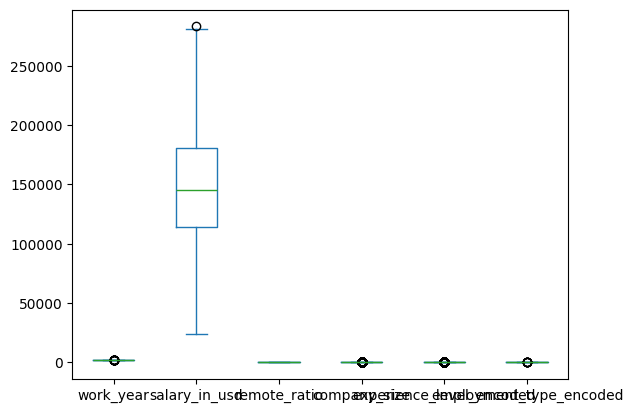

      work_year experience_level employment_type       job_title  \
9          2023               SE              FT  Data Scientist   
10         2023               SE              FT  Data Scientist   
11         2023               SE              FT    Data Analyst   
12         2023               SE              FT    Data Analyst   
17         2023               SE              FT  Data Scientist   
...         ...              ...             ...             ...   
3737       2021               MI              FT    Data Analyst   
3738       2021               MI              FT  Data Scientist   
3741       2020               MI              FT  Data Scientist   
3742       2020               MI              FT  Data Scientist   
3752       2020               EN              FT  Data Scientist   

      salary_in_usd  remote_ratio company_size  experience_level_encoded  \
9            147100             0            M                         3   
10            90700            

In [83]:
# outlier detection using IQR
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['salary_in_usd'] >= lower_bound) & (df['salary_in_usd'] <= upper_bound)]

# Visualize
df.plot(kind='box')
plt.show()


df1.reset_index()
print(df1)

In [84]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Copy the original DataFrame
df1 = df.copy()

# 2. Apply Label Encoding to all categorical columns
categorical_cols = ['experience_level', 'job_title', 'employment_type', 'company_size']
le = LabelEncoder()
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])

# 3. Scale numerical features (including encoded categorical features)
numeric_features = ['work_year', 'remote_ratio'] + categorical_cols
scaler = StandardScaler()
df1[numeric_features] = scaler.fit_transform(df1[numeric_features])

# 4. Create X (features) and y (target)
X_data = df1.drop(columns=['salary_in_usd'])
y_data = df1['salary_in_usd']

# 5. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42)

# 6. Train the Random Forest model
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

# 7. Make predictions on the test set
y_pred = rf.predict(X_test)


In [85]:
# With so many jobs, extracting the top 5 most jobs
top_5_job_titles = df['job_title'].value_counts().nlargest(5).index.tolist()

# Create a new data frame that includes only the top 5 jobs
df1 = df[df['job_title'].isin(top_5_job_titles)]

# Label encoding
le = LabelEncoder()
df1['job_title_encoded'] = le.fit_transform(df1['job_title'])

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])

# Label Encoding
le = LabelEncoder()
df['company_size'] = le.fit_transform(df['company_size'])


<ipython-input-85-439ecaaa7ada>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['job_title_encoded'] = le.fit_transform(df1['job_title'])
<ipython-input-85-439ecaaa7ada>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['experience_level_encoded'] = le.fit_transform(df['experience_level'])
<ipython-input-85-439ecaaa7ada>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

In [86]:
### Check the index of training data

# Check the index of X_train
print(X_train.index)

print('-'*80)

# Check the index of y_train
print(y_train.index)

Index([ 449,  983, 2269,  802,  827, 2477, 2936, 3117, 2292, 1042,
       ...
       1766,  392, 1481,  547, 2595, 1956, 1303, 1360, 1541, 1015],
      dtype='int64', length=2344)
--------------------------------------------------------------------------------
Index([ 449,  983, 2269,  802,  827, 2477, 2936, 3117, 2292, 1042,
       ...
       1766,  392, 1481,  547, 2595, 1956, 1303, 1360, 1541, 1015],
      dtype='int64', length=2344)


### Predicting Salary Using Decision Tree Regression

#### Creating the best model

In [87]:
### Model Optimization

# Import necessary library
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Creating a Baseline Model for Optimization
base_dt = DecisionTreeRegressor(random_state=0)

# Setting the parameters to optimize and search conditions
depth = np.arange(3,11)
params = {'max_depth':depth}

# Creating Models for Cross-Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

# Creating Exploratory Models
grid_dt = GridSearchCV(
    estimator=base_dt,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=kfold
)

# Training and Evaluating Exploratory Models
grid_dt.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=DecisionTreeRegressor(random_state=0),
             param_grid={'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='neg_mean_squared_error')

In [88]:
### Tuning hyperparameters
print(grid_dt.best_params_)

{'max_depth': np.int64(6)}


In [89]:
### Creating the best model
best_dt = DecisionTreeRegressor(max_depth=4, random_state=0)

#### Training the best model

In [90]:
best_dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=0)

#### Predictions on a test set

In [91]:
pred_test = best_dt.predict(X_test)

#### Evaluation the best model

In [92]:
# Import necessary library
from sklearn.metrics import mean_squared_error as mse

# Measuring performance on a test set
mse_test = mse(y_test, pred_test)

# Check the result
print(f'performance on a test set : {mse_test}')

performance on a test set : 1876813675.8059058


In [93]:
### Measuring RMSE
rmse = np.sqrt(mse_test)
print(f'rmse on a test set: {rmse}')

rmse on a test set: 43322.20765157179


In [94]:
print(y_test.describe())

count       586.000000
mean     151992.500000
std       48549.645379
min       24000.000000
25%      120000.000000
50%      150000.000000
75%      182415.000000
max      283200.000000
Name: salary_in_usd, dtype: float64


### Predicting salary Using LightGBM Regression

In [95]:
# Import necessary library
from lightgbm import LGBMRegressor

# Creating a Baseline Model for Optimization
base_lgbm  = LGBMRegressor(random_state=0,
                           bagging_seed=0,
                           feature_fraction_seed=0,
                           data_random_seed=0,
                           drop_seed=0,
                           verbose=-1)

# Setting the parameters to optimize and search conditions
depth=np.arange(3,11)
params = {'n_estimators':[50, 100, 200, 300, 400, 500],
          'learning_rate':[0.01, 0.05, 0.1, 0.2, 0.5],
          'max_depth':depth}

# Creating Models for Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

# Creating Exploratory Models
grid_lgbm = GridSearchCV(
    estimator=base_lgbm,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=kfold
)

# Training and Evaluating Exploratory Models
grid_lgbm.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=LGBMRegressor(bagging_seed=0, data_random_seed=0,
                                     drop_seed=0, feature_fraction_seed=0,
                                     random_state=0, verbose=-1),
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
                         'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10]),
                         'n_estimators': [50, 100, 200, 300, 400, 500]},
             scoring='neg_mean_squared_error')

In [96]:
### Creating the best model
best_lgbm = LGBMRegressor(random_state=0,
                           bagging_seed=0,
                           feature_fraction_seed=0,
                           data_random_seed=0,
                           drop_seed=0,
                           verbose=-1,
                          learning_rate=0.1,
                          max_depth=4,
                          n_estimators=500)

#### Training the best model

In [97]:
best_lgbm.fit(X_train,y_train)

LGBMRegressor(bagging_seed=0, data_random_seed=0, drop_seed=0,
              feature_fraction_seed=0, max_depth=4, n_estimators=500,
              random_state=0, verbose=-1)

#### Predictions on a test set

In [98]:
pred_test = best_lgbm.predict(X_test)

#### Evaluating the best model

In [99]:
# Measuring performance on a test set
mse_test = mse(y_test, pred_test)

# Check the result
print(f'mse on a test set : {mse_test}')

mse on a test set : 1835560559.3872


In [100]:
### Measuring the rmse
rmse = np.sqrt(mse_test)
print(f'rmse on a test set : {rmse}')

rmse on a test set : 42843.44243156938
